# State Space Extension

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
import pandas as pd
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from dynamics import *
from simulations import *
from dimensionality_reduction import *
from metrics import *
from state_space import *
rng = np.random.default_rng(0)

### Goal:

Previously, we have seen how principal component analysis (PCA) can recover low-dimensional structure from simulated neural activity. However, PCA does not explicitly model the temporal dynamics of the latent neural state.

In this notebook, we introduce the linear Gaussian state-space model underlying our simulation and compare PCA with a basic Kalman filter, which incorporates both temporal dynamics and noisy observations. We compare its ability to model the latent-state dynamics with PCA through calculating the latent-state mean squared error and examining their trajectories. 

### Generate Simulated Data

In [2]:
theta = np.pi/4
r = 0.98
x0 = np.array([1.0, 1.0])
T = 100
process_noise_std = 0.5
observation_noise_std = 1.00
A = damped_rotation_matrix(theta, r)
X = simulate_linear_system(A, x0, T, process_noise_std, rng=rng)

n_neurons = 100
latent_dim = x0.shape[0]

C = generate_observation_matrix(n_neurons, latent_dim, scale=1.0, rng=rng)
Y = X @ C.T
Y = add_observation_noise(Y, observation_noise_std, rng=rng)

We generate a single recording of neural population activity with the same latent dynamical system from previous notebooks. To highlight the distinction between static and dynamics estimation, observation noise is chosen to be higher than process noise. Here, individual neural observations are unreliable while latent dynamics remain relatively predicatable.

## State-Space Model

Throughout this project, we stimulated hidden neural activity that evolved over time. Despite analyzing these simulations using PCA, the underlying simulation was a linear Gaussian state-space model from the very beginning. 

The first equation: $x_{t+1} = Ax_t + w_t$ is the state equation; it describes how the latent state evolves over time. The next equation: $y_t = Cx_t + \varepsilon_t$ is the observation equation; it describes how the neural population activity evolves over time.

These equations correspond exactly to the simulation pipelinen developed throughout the project:
1. A low dimensional hidden neural state evolves according to the state equation. 
2. The hidden state is projected into a larger neural population through the observation matrix C.
3. Observation noise is added to simulate imperfect neural recordings.

## PCA Limitations

While PCA recovered low-dimensional structure from the neural observations, it does not use the state equation. State-space methods instead estimate hidden neural states by combining both the state equation and the observation equation.

PCA directly receives the observation matrix Y and identifices the directions of maximum variance to determine the hidden two-dimensional latent subspace from the high-dimensional neural data. However, it does not use the relationship described by the state equation as it treats each neural observation as an independent sample when computing the principal components 

Because PCA ignores temporal dynamics, it cannot use knowledge of how latent neural states evolve when estimating hidden activity. State-space models address this by combining predictions from the dynamical model with incoming observations, allowing both sources of information to contribute to the latent-state estimate.

## Experiment: PCA vs. Kalman Filter

In [3]:
# Run PCA
n_components = 2
Z_pca, pca_model = run_pca(Y, n_components)

# Align PCA with True Latent-State Coordinates
X_mean = X.mean(axis=0)
X_centered = X - X_mean
Z_pca_centered = Z_pca - Z_pca.mean(axis=0)

alignment_matrix = Z_pca_centered.T @ X_centered
U, _, Vt = np.linalg.svd(alignment_matrix)
rotation = U @ Vt

Z_pca_aligned = Z_pca_centered @ rotation

scale = (np.sum(X_centered * Z_pca_aligned)/ np.sum(Z_pca_aligned**2))
Z_pca_aligned *= scale
Z_pca_aligned += X_mean

# Run Kalman Filter
x0_estimate = np.zeros(latent_dim)
P0 = np.eye(latent_dim)

Q = process_noise_std**2 * np.eye(latent_dim)
R = observation_noise_std**2 * np.eye(n_neurons)

X_filtered, P_filtered = kalman_filter(Y, A, C, Q, R, x0_estimate, P0)

The Kalman filter requires covariance matrices describing the error in both parts of the state-space model. Since simulated proess and observation noise are independent and Gaussian, their covariance matrices are constructed directly from the corresponding noise variances: \
$$Q = \sigma_w^2 I, \qquad R = \sigma_\varepsilon^2 I$$
The filter also begins with an intial state estimate and an associated uncertainty $P$. We initialize the estimatesd state at zero and use an identity covariane matrix to represent $P_0$. As this is a controlled simulation, the Kalman filter is given the true matrices $A$, $C$, $Q$, and $R$ used to generate the data.


## Experiment: Results

Recovery is evaluated using latent-state mean squared error:
$$
\frac{1}{Td}
\sum_{t=1}^{T}
\left|
x_t-\hat{x}_t
\right|^2.
$$
Lower MSE indicates that the estimated trajectory is closer to the true hidden state.

,Latent-State MSE
Aligned PCA,0.012929
Kalman Filter,0.008018


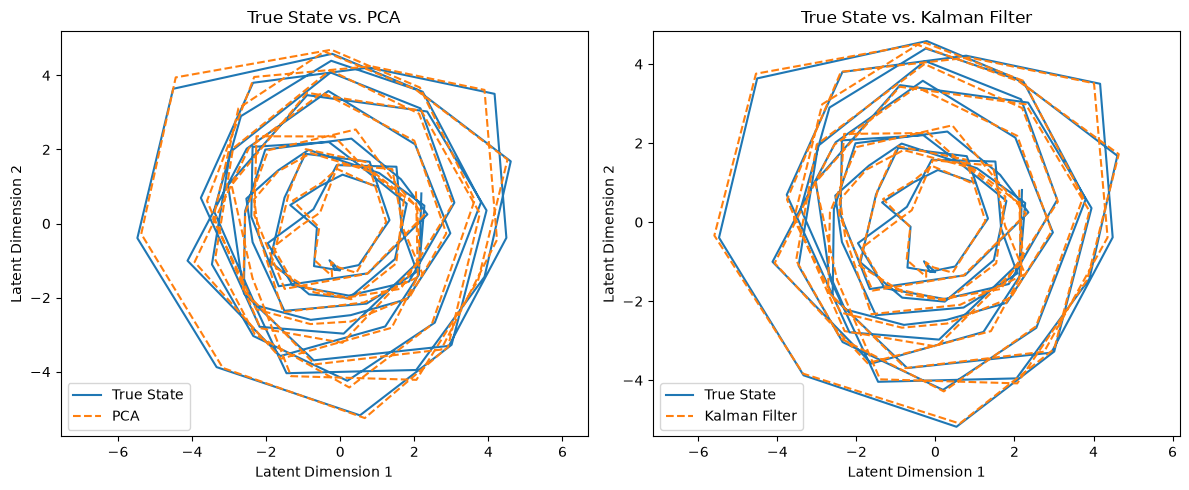

In [4]:
# Plotting
fig, axes = subplots(1, 2, figsize=(12, 5))

# PCA vs. True State
axes[0].plot(X[:, 0], X[:, 1], label="True State")
axes[0].plot(Z_pca_aligned[:, 0], Z_pca_aligned[:, 1], linestyle="--", label="PCA")
axes[0].set_title("True State vs. PCA")
axes[0].set_xlabel("Latent Dimension 1")
axes[0].set_ylabel("Latent Dimension 2")
axes[0].axis("equal")
axes[0].legend()

# Kalman Filter vs. True State
axes[1].plot(X[:, 0], X[:, 1], label="True State")
axes[1].plot(X_filtered[:, 0], X_filtered[:, 1], linestyle="--", label="Kalman Filter")
axes[1].set_title("True State vs. Kalman Filter")
axes[1].set_xlabel("Latent Dimension 1")
axes[1].set_ylabel("Latent Dimension 2")
axes[1].axis("equal")
axes[1].legend()

fig.tight_layout()

# Mean Squared Error
pca_mse = np.mean((X - Z_pca_aligned) ** 2)
kalman_mse = np.mean((X - X_filtered) ** 2)

results = pd.DataFrame({"Latent-State MSE": [pca_mse, kalman_mse,]}, 
    index=[
        "Aligned PCA",
        "Kalman Filter",
    ])

display(results)

The trajectory plots show that both PCA and the Kalman filter successfully recover the overall structure of the latent neural dynamics. After alignment, the PCA-recovered trajectory closely follows the true latent trajectory, confirming the results from the previous notebook.

The Kalman-filter estimate also closely matches the trajectory and appears to follow the latent dynamics slightly more consistently than PCA. This improvement is reflected in the latent-state mean squared error. The aligned PCA reconstruction achieved an MSE of **0.012929** while the Kalman filter achieved an MSE of **0.008018**. Although both methods recover the underlying state well, the Kalman filter benefits from explicitly modeling how the hidden state evolves over time.

## Conclusion

This notebook extended the proeject form stating dimensionality reduction to dynamic state-space modeling. PCA can successfully recover the low-dimensional structure of simulated neural activity, but it fails to model temporal evolution.

The Kalman filter addresses this issue by combining predictions from the dynamical model with incoming observations to estimate the hidden state. In this simulation, incorporating the known system dynamics produced increased the accuracy of the estimate of the latent trajectory compared to PCA.

This highlights an important distinction in computational neuroscience. Dimensionality reduction methods like PCA are useful for recovering low-dimensional representations of neural activity, whereas state-space models provide a generative framework that describes how hidden neural states evolve and give rise to observed population activity.